# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

# 1. Load Datasets

In [1]:
pip install pandas numpy matplotlib seaborn plotly scipy

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Plot style
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
# Load Historical Trading Data
trader_df = pd.read_csv("/content/fear_greed_index.csv")

# Load Fear & Greed Dataset
sentiment_df = pd.read_csv("/content/historical_data.csv")

In [5]:
trader_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
sentiment_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
print(trader_df.shape)

print(sentiment_df.shape)

(2644, 4)
(200513, 16)


In [8]:
print(trader_df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [9]:
print(sentiment_df.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [10]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [11]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200513 entries, 0 to 200512
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           200513 non-null  object 
 1   Coin              200513 non-null  object 
 2   Execution Price   200513 non-null  float64
 3   Size Tokens       200513 non-null  float64
 4   Size USD          200513 non-null  float64
 5   Side              200513 non-null  object 
 6   Timestamp IST     200513 non-null  object 
 7   Start Position    200513 non-null  float64
 8   Direction         200513 non-null  object 
 9   Closed PnL        200513 non-null  float64
 10  Transaction Hash  200513 non-null  object 
 11  Order ID          200513 non-null  int64  
 12  Crossed           200513 non-null  bool   
 13  Fee               200513 non-null  float64
 14  Trade ID          200513 non-null  float64
 15  Timestamp         200513 non-null  float64
dtypes: bool(1), float64(

In [12]:
trader_df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [13]:
sentiment_df.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,200513,200513,200513.000000,2.005130e+05,2.005130e+05,200513,200513,2.005130e+05,200513,200513.000000,200513,2.005130e+05,200513,200513.000000,2.005130e+05,2.005130e+05
unique,29,245,NaN,NaN,NaN,2,27391,NaN,12,NaN,96469,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,66386,NaN,NaN,NaN,102897,441,NaN,48309,NaN,8677,NaN,122389,NaN,NaN,NaN
mean,NaN,NaN,11408.263320,4.787846e+03,5.560178e+03,NaN,NaN,-3.037766e+04,NaN,47.832019,NaN,6.919773e+10,NaN,1.134290,5.628966e+14,1.737480e+12
std,NaN,NaN,29497.436097,1.068681e+05,3.696767e+04,NaN,NaN,6.905361e+05,NaN,895.438083,NaN,1.855992e+10,NaN,6.720297,3.256588e+14,9.564568e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.730000e+00
25%,NaN,NaN,5.240000,3.002300e+00,1.861000e+02,NaN,NaN,-2.549900e+02,NaN,0.000000,NaN,5.860777e+10,NaN,0.015365,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.180000,3.200000e+01,5.824800e+02,NaN,NaN,1.506230e+02,NaN,0.000000,NaN,7.440090e+10,NaN,0.086875,5.620000e+14,1.740000e+12
75%,NaN,NaN,32.142000,1.780000e+02,2.026280e+03,NaN,NaN,9.879620e+03,NaN,5.808563,NaN,8.239360e+10,NaN,0.380689,8.460000e+14,1.740000e+12


In [14]:
trader_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [15]:
sentiment_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [16]:
print(trader_df.duplicated().sum())

print(sentiment_df.duplicated().sum())

0
0


In [17]:
# Fear & Greed Dataset
fear_greed_df = trader_df.copy()

# Historical Trading Dataset
trades_df = sentiment_df.copy()

#2. Data Cleaning

In [18]:
print("Fear & Greed Duplicates:", fear_greed_df.duplicated().sum())
print("Trades Duplicates:", trades_df.duplicated().sum())

Fear & Greed Duplicates: 0
Trades Duplicates: 0


In [19]:
fear_greed_df.drop_duplicates(inplace=True)
trades_df.drop_duplicates(inplace=True)

In [20]:
print(fear_greed_df.isnull().sum())
print(trades_df.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [21]:
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"])

In [22]:
fear_greed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [23]:
trades_df["Timestamp IST"] = pd.to_datetime(
    trades_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [24]:
trades_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200513 entries, 0 to 200512
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           200513 non-null  object        
 1   Coin              200513 non-null  object        
 2   Execution Price   200513 non-null  float64       
 3   Size Tokens       200513 non-null  float64       
 4   Size USD          200513 non-null  float64       
 5   Side              200513 non-null  object        
 6   Timestamp IST     200513 non-null  datetime64[ns]
 7   Start Position    200513 non-null  float64       
 8   Direction         200513 non-null  object        
 9   Closed PnL        200513 non-null  float64       
 10  Transaction Hash  200513 non-null  object        
 11  Order ID          200513 non-null  int64         
 12  Crossed           200513 non-null  bool          
 13  Fee               200513 non-null  float64       
 14  Trad

In [25]:
trades_df["date"] = trades_df["Timestamp IST"].dt.date

In [26]:
fear_greed_df["date"] = fear_greed_df["date"].dt.date

In [27]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [28]:
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [29]:
print("Fear & Greed Date Range")
print(fear_greed_df["date"].min())
print(fear_greed_df["date"].max())

Fear & Greed Date Range
2018-02-01
2025-05-02


In [30]:
print("Trades Date Range")
print(trades_df["date"].min())
print(trades_df["date"].max())

Trades Date Range
2023-05-01
2025-05-01


#Merge the Datasets

In [31]:
merged_df = pd.merge(
    trades_df,
    fear_greed_df,
    on="date",
    how="left"
)

In [32]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [33]:
merged_df[["date", "classification"]].head(20)

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


#3. EDA

In [34]:
print("Rows:", merged_df.shape[0])
print("Columns:", merged_df.shape[1])

merged_df.head()

Rows: 200513
Columns: 20


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


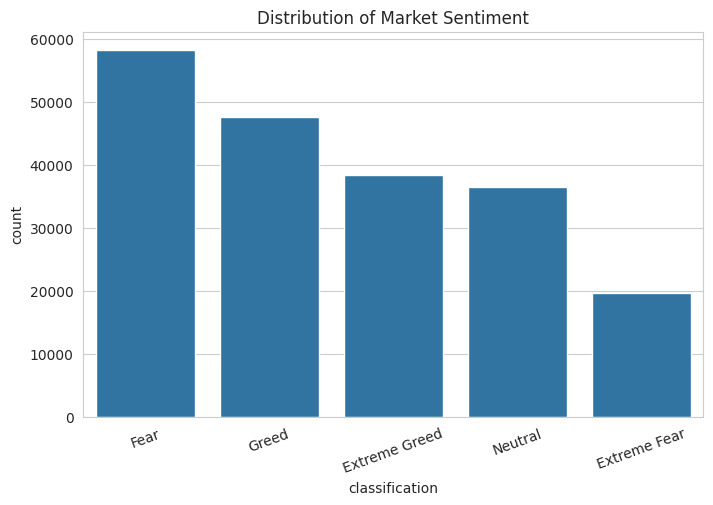

In [35]:
#Sentiment Distribution
#Most trades occurred during Greed and Extreme Greed, indicating higher market activity in bullish conditions

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xticks(rotation=20)
plt.show()

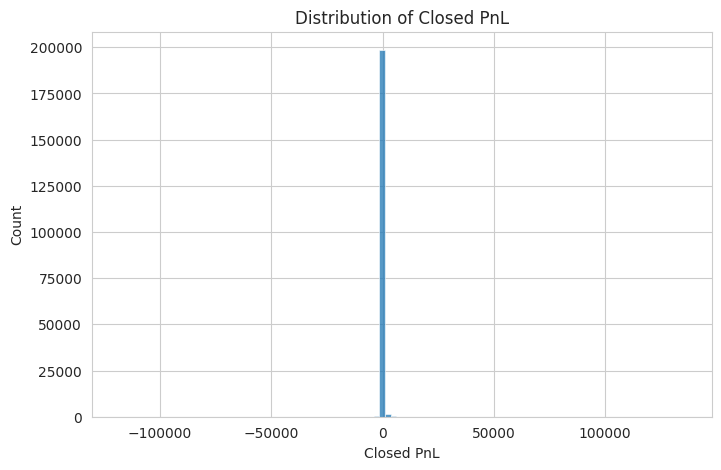

In [36]:
#Closed PnL Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    merged_df["Closed PnL"],
    bins=100
)

plt.title("Distribution of Closed PnL")
plt.show()

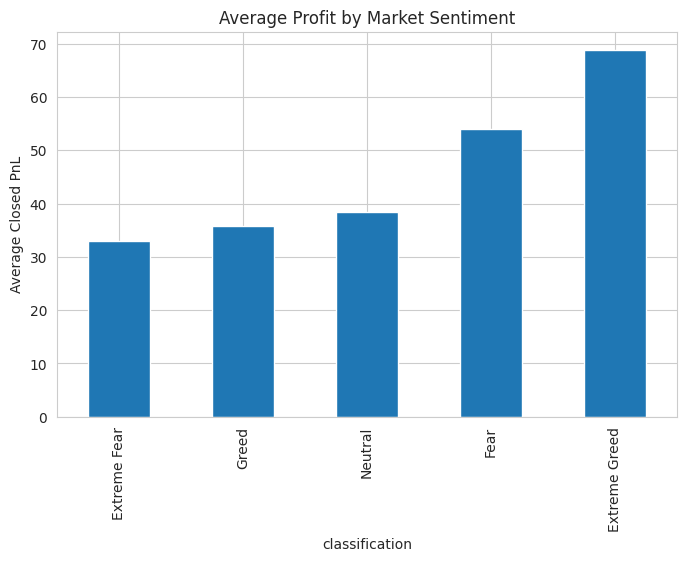

In [37]:
#Average PnL by Market Sentiment
plt.figure(figsize=(8,5))

merged_df.groupby("classification")["Closed PnL"].mean().sort_values().plot(
    kind="bar"
)

plt.ylabel("Average Closed PnL")
plt.title("Average Profit by Market Sentiment")
plt.show()

• Average Closed PnL is highest during Extreme Greed (~69), followed by Fear (~54).

• Extreme Fear has the lowest average profit (~33).

• This suggests traders generated better average profits during bullish market conditions.

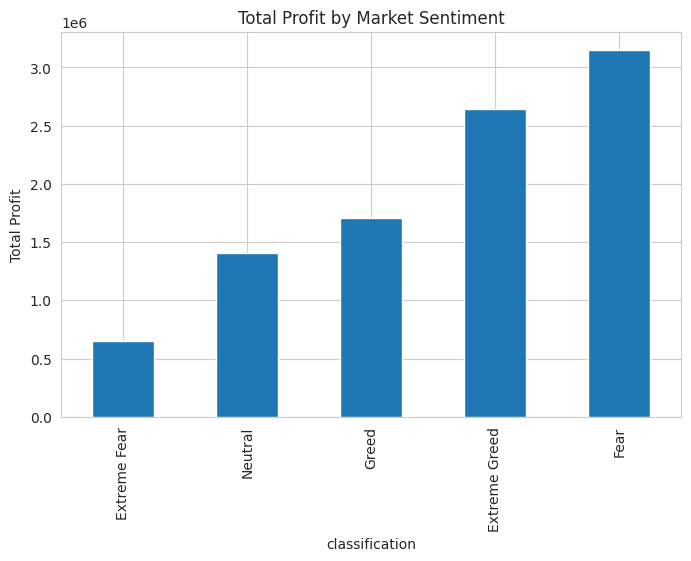

In [38]:
#Total Profit by Sentiment
plt.figure(figsize=(8,5))

merged_df.groupby("classification")["Closed PnL"].sum().sort_values().plot(
    kind="bar"
)

plt.ylabel("Total Profit")
plt.title("Total Profit by Market Sentiment")
plt.show()

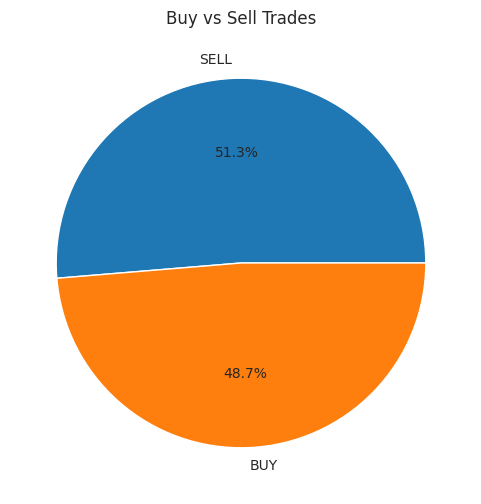

In [39]:
#BUY vs SELL
plt.figure(figsize=(6,6))

merged_df["Side"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Buy vs Sell Trades")
plt.show()

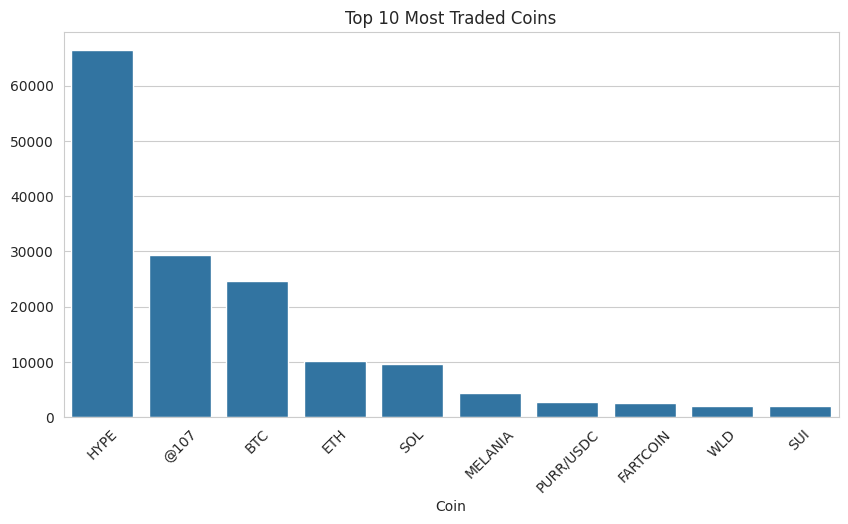

In [40]:
#Coin-wise Trading Volume
top_coins = merged_df["Coin"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_coins.index,
    y=top_coins.values
)

plt.title("Top 10 Most Traded Coins")
plt.xticks(rotation=45)

plt.show()

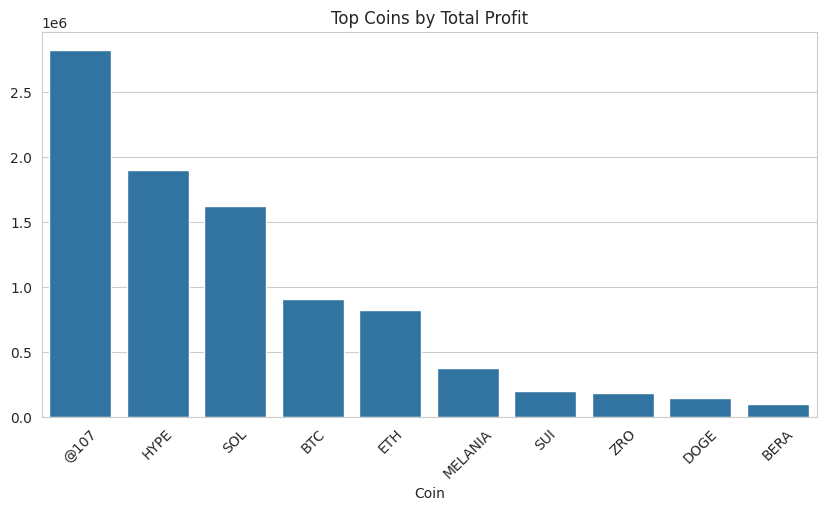

In [41]:
#Coin-wise Profit
coin_profit = merged_df.groupby("Coin")["Closed PnL"].sum()

coin_profit = coin_profit.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=coin_profit.index,
    y=coin_profit.values
)

plt.title("Top Coins by Total Profit")
plt.xticks(rotation=45)

plt.show()

• @107 generated the highest cumulative profit among all traded assets.

• HYPE and SOL also contributed significantly to total profitability.

• BTC and ETH were profitable but ranked below the top-performing assets.

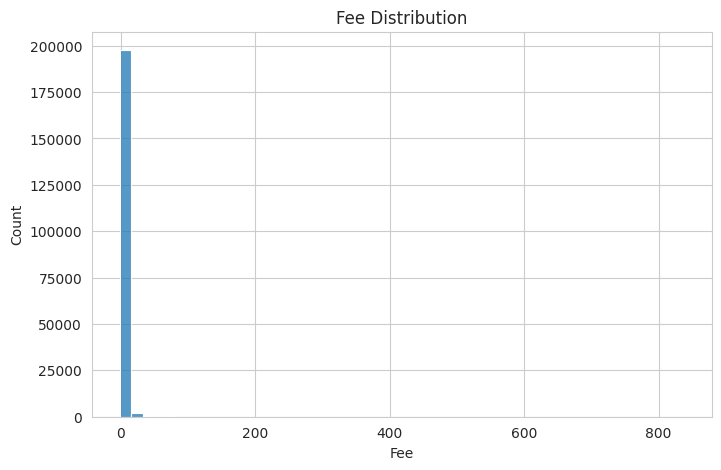

In [42]:
#Fees Analysis
plt.figure(figsize=(8,5))

sns.histplot(
    merged_df["Fee"],
    bins=50
)

plt.title("Fee Distribution")

plt.show()

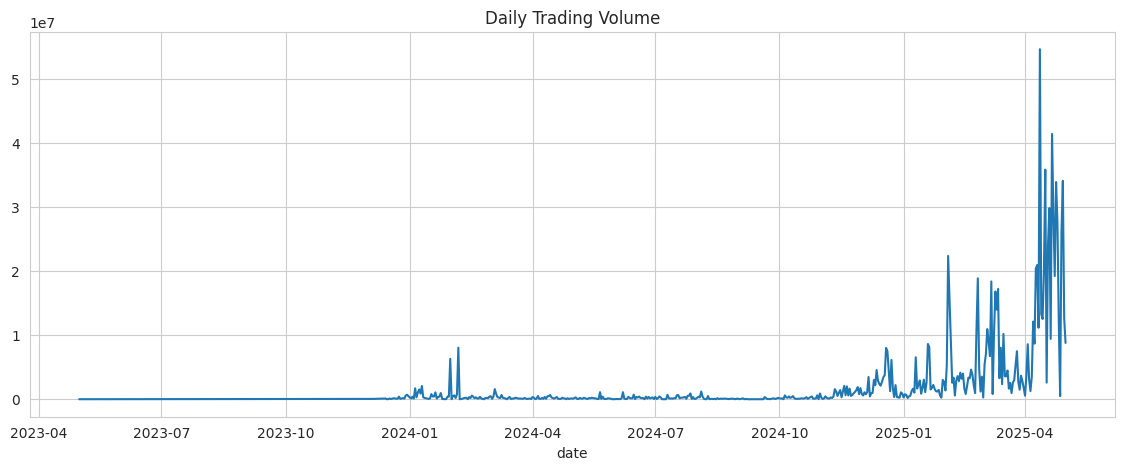

In [43]:
#Trading Volume over Time
daily_volume = merged_df.groupby("date")["Size USD"].sum()

plt.figure(figsize=(14,5))

daily_volume.plot()

plt.title("Daily Trading Volume")

plt.show()

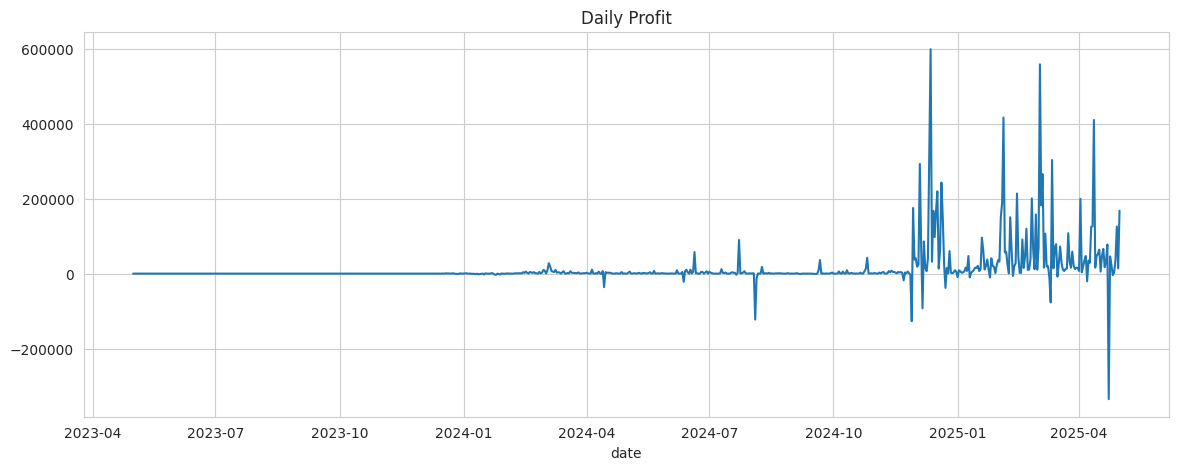

In [44]:
#Profit over Time
daily_profit = merged_df.groupby("date")["Closed PnL"].sum()

plt.figure(figsize=(14,5))

daily_profit.plot()

plt.title("Daily Profit")

plt.show()

• Daily profits remain relatively stable in early periods.

• Profit volatility increases significantly during late 2024 and early 2025.

• Several days recorded exceptionally high profits as well as substantial losses, indicating increased market volatility.

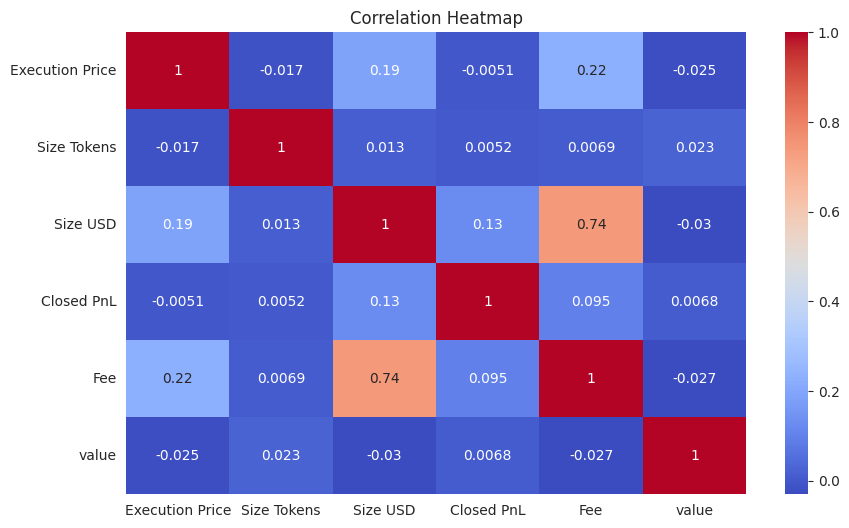

In [45]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee",
    "value"
]

sns.heatmap(
    merged_df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

• Size USD and Fee have a strong positive correlation (≈0.74), which is expected because larger trades incur higher fees.

• Closed PnL has only weak correlations with other numerical variables.

• Market sentiment value has almost no linear correlation with individual trade profit.

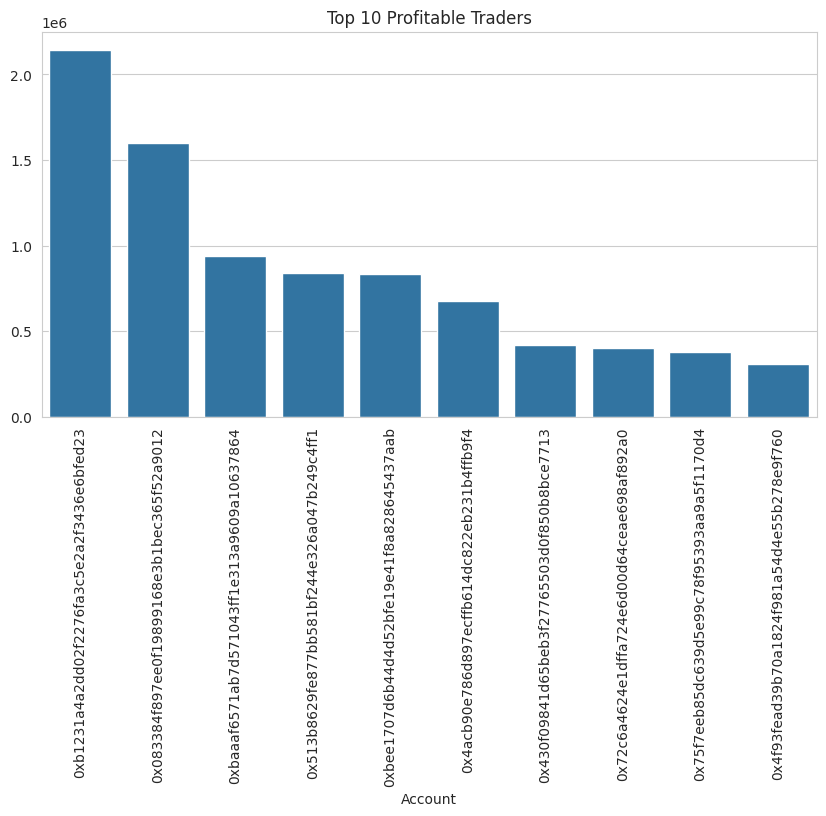

In [46]:
#Top 10 Traders by Profit
top_traders = merged_df.groupby("Account")["Closed PnL"].sum()

top_traders = top_traders.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_traders.index,
    y=top_traders.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Profitable Traders")

plt.show()

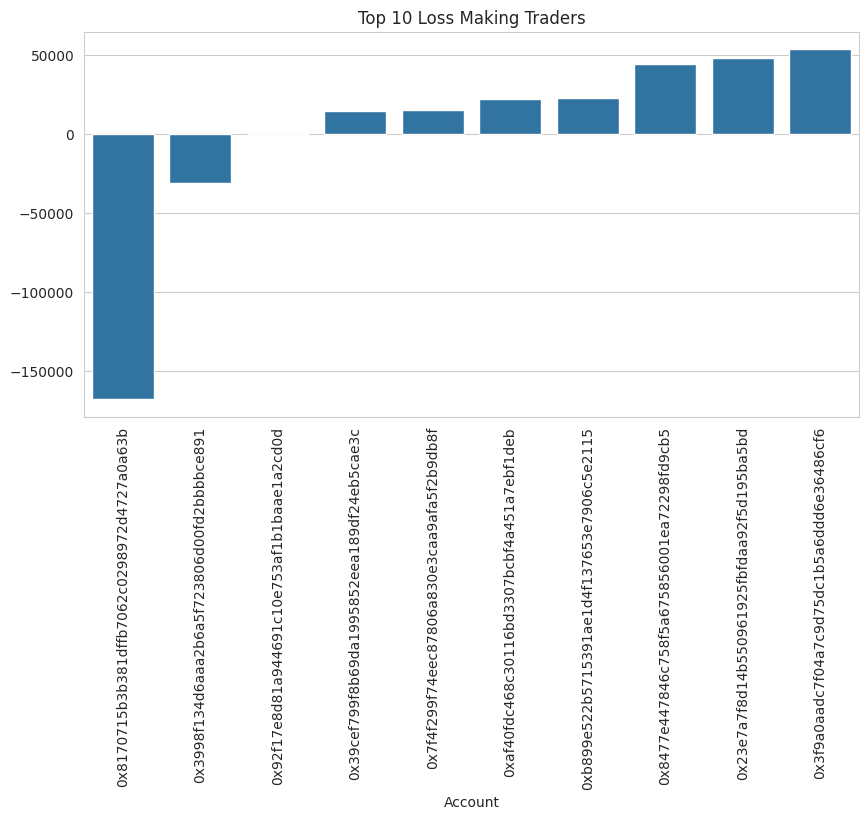

In [47]:
#Top 10 Losing Traders
loss_traders = merged_df.groupby("Account")["Closed PnL"].sum()

loss_traders = loss_traders.sort_values().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=loss_traders.index,
    y=loss_traders.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Loss Making Traders")

plt.show()

In [48]:
#Win Rate
merged_df["Win"] = merged_df["Closed PnL"] > 0

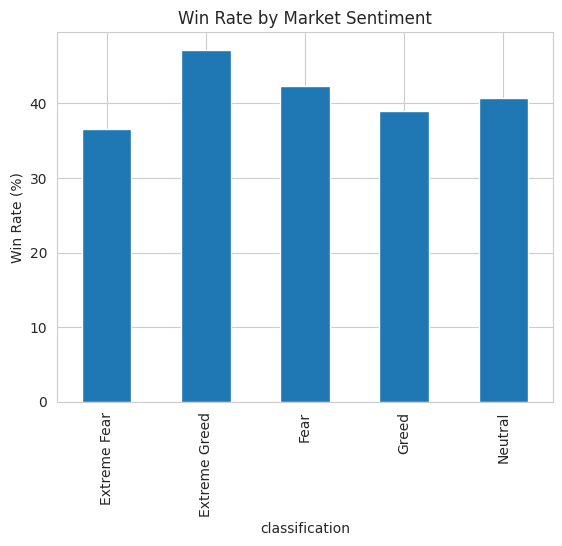

In [49]:
win_rate = merged_df.groupby("classification")["Win"].mean() * 100

win_rate.plot(kind="bar")

plt.ylabel("Win Rate (%)")

plt.title("Win Rate by Market Sentiment")

plt.show()

• Extreme Greed shows the highest win rate (~47%).

• Fear has a higher win rate than Greed.

• Extreme Fear records the lowest win rate (~36%), indicating challenging trading conditions.

In [50]:
summary = merged_df.groupby("classification").agg(
    Total_Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Fee=("Fee","mean"),
    Avg_Size_USD=("Size USD","mean")
)

summary

,Total_Trades,Average_PnL,Total_PnL,Avg_Fee,Avg_Size_USD
classification,,,,,
Extreme Fear,19639,32.959157,6.472849e+05,1.067577,5188.171221
Extreme Greed,38411,68.829364,2.643805e+06,0.671532,3090.631773
Fear,58286,54.028019,3.149077e+06,1.472055,7828.238662
Greed,47621,35.825399,1.706041e+06,1.221456,5616.695913
Neutral,36550,38.365570,1.402262e+06,1.004213,4663.342020


In [51]:
#Win Rate Table
win_table = merged_df.groupby("classification").agg(
    Win_Rate=("Win","mean")
)

win_table["Win_Rate"] = win_table["Win_Rate"]*100

win_table

,Win_Rate
classification,
Extreme Fear,36.605733
Extreme Greed,47.202624
Fear,42.318910
Greed,38.949203
Neutral,40.746922


In [52]:
#Top 10 Profitable Traders
top_traders = merged_df.groupby("Account").agg(
    Total_Profit=("Closed PnL","sum"),
    Trades=("Closed PnL","count")
)

top_traders = top_traders.sort_values(
    by="Total_Profit",
    ascending=False
)

top_traders.head(10)

,Total_Profit,Trades
Account,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,1430
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,9893


In [53]:
#Statistical Test (T-Test)
from scipy.stats import ttest_ind

fear = merged_df[
    merged_df["classification"].isin(["Fear","Extreme Fear"])
]["Closed PnL"]

greed = merged_df[
    merged_df["classification"].isin(["Greed","Extreme Greed"])
]["Closed PnL"]

t_stat, p_value = ttest_ind(
    fear,
    greed,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.38672648962763617
P-value: 0.6989592160250496


- An independent t-test was conducted
to compare the Closed PnL between Fear (Fear + Extreme Fear) and Greed (Greed + Extreme Greed) market conditions.

- The obtained p-value (0.699) is much greater than the significance level of 0.05.

- Therefore, we fail to reject the null hypothesis. The analysis indicates that there is no statistically significant difference in average Closed PnL between Fear and Greed market conditions.




# Summary of Analysis

In [54]:
summary = merged_df.groupby("classification").agg(
    Total_Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Fee=("Fee","mean"),
    Avg_Size_USD=("Size USD","mean")
)

summary

,Total_Trades,Average_PnL,Total_PnL,Avg_Fee,Avg_Size_USD
classification,,,,,
Extreme Fear,19639,32.959157,6.472849e+05,1.067577,5188.171221
Extreme Greed,38411,68.829364,2.643805e+06,0.671532,3090.631773
Fear,58286,54.028019,3.149077e+06,1.472055,7828.238662
Greed,47621,35.825399,1.706041e+06,1.221456,5616.695913
Neutral,36550,38.365570,1.402262e+06,1.004213,4663.342020


## Interpretation

- Extreme Greed recorded the highest average profit per trade.
- Fear generated the highest total profit due to the largest number of trades.
- Extreme Fear had the lowest average profit and win rate.

# Final Insights
1. Extreme Greed recorded the highest average profit per trade.
2. Fear market conditions generated the highest cumulative profit.
3. Extreme Fear had the lowest win rate.
4. Trading activity was highest during Fear conditions.
5. Coin @107 generated the highest cumulative profit.
6. Fee is strongly correlated with trade size.
7. Daily profits became more volatile in late 2024 and early 2025.
8. Statistical testing showed no significant difference in profitability between Fear and Greed conditions.

# Business Recommendations
- Do not rely solely on the Fear & Greed Index for trading decisions.
- Combine market sentiment with technical indicators.
- Follow proper risk management and position sizing.
- Monitor market volatility before executing trades.
- Use multiple indicators to improve trading performance.